# Computing for Economists: Numerical Simulation
---


In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

***Note:*** ```PyMC``` requires Python verson 3.10 or greater, otherwise dependency issues might occur. Downgrading ```SciPy``` to version 1.12.0 may also resolve the issue. Create either a virtual environment to make these changes, or feel free to do the first exercises on Google colab! The latter may be more efficient if you are running into library issues for the first problem.

## Exercise: Posterior Sampling with PyMC

In this problem, we'll consider a simple Bayesian sampling problem and compare MCMC to Variational Inference using [```PyMC```](https://www.pymc.io/welcome.html). By default, ```PyMC``` uses [NUTS](https://arxiv.org/abs/1111.4246) for MCMC and [ADVI](https://arxiv.org/abs/1603.00788) for Variational Inference (VI). NUTS is a modification of gradient-based MCMC algorithms (namely Hamiltonian Monte Carlo), and ADVI uses automatic differentiation to efficiently compute gradients in VI. While it is possible to manually call on Metropolis-Hastings, NUTS is much more efficient for continuous problems. ```PyMC``` automatically chooses the family of distributions behind the scenes (e.g. Gaussian, Gamma) using the mean-field approximation when performing VI.

Let's consider how we might estimate the parameters of a [multinomial probit model](https://en.wikipedia.org/wiki/Multinomial_probit#:~:text=The%20multinomial%20probit%20model%20is%20a%20statistical%20model%20that%20can,variables%20on%20the%20different%20outcomes.). Suppose consumer $i$ with characteristics $X_i$ is faced with three options of cereal $\{1, 2, 3\}$. The consumer chooses the cereal based on a categorical distribution (i.e. multinomial with one event) with the choice probabilities determined by the softmax function:

\begin{align*}
Y_i|X_i & \sim Categorical(p_i^1, p_i^2, p_i^3) \\  
p_i^k & = \frac{\exp(X_i\beta_k)}{\Sigma_{k'=1}^3 \exp(X_i\beta_{k'})}, \text{ for } k= \{1, 2, 3\}
\end{align*}

We have the same prior on all coefficients $\beta \sim \mathcal{N}(0, \sigma^2)$ where $\sigma^2 = 4$. Assume the coefficients are not correlated under the prior.

<font color = 'orange'> [AI Edit & Human Review]</font> Generate a data sample $(Y, X)$ of $N$ points using the given set of coefficient values. Start with $N = 100$.

In [2]:
true_beta = np.array([[1, 2.5, -3],  # Coefficients including intercepts
                      [0.5, -0.9, 0.5],
                      [-1, -1, 2]])

In [3]:
def softmax(x):
    # Shift the inputs to softmax to a more numerically stable range
    z = x - x.max(axis=1, keepdims=True)
    numerator = np.exp(z)
    denominator = np.sum(numerator, axis=1, keepdims=True)
    return numerator / denominator

def DGP(N):
    np.random.seed(1)

    # Covariate matrix with intercept
    X = np.hstack((np.ones((N, 1)), np.random.normal(size=(N, 2))))

    utility = np.dot(X, true_beta.T)

    p = softmax(utility)
    Y = np.eye(3)[np.array([np.random.choice(3, p=p_i) for p_i in p])]  # One-hot encode the choices

    return (Y, X)

Y, X = DGP(100)

1. <font color='red'> [Write it yourself]</font> Based on the 100 data observations and given prior, write a function with ```PyMC``` to sample the posterior distributions of $\beta$. There should be nine coefficients, one for each covariate $\times$ choice of cereal. Wrap your ```PyMC``` model in a function that takes data inputs $(Y, X)$ and a string for method ```MCMC``` or ```VI```. The latter should only generate a difference in the last line which specifies estimation.

***Tips:*** Within ```pm.Model()```, you should only be using functions defined by the ```PyMC``` library, including the ```pymc.math``` library. Be careful to adjust for overflow and numerical instability when using ```PyMC```'s softmax. We have given you the general outline of the code, and you will have to fill in ```# Your code here```.

In [4]:
def mnp_pymc(Y, X, method='MCMC'):
    with pm.Model() as model:
        # Priors for coefficients
        beta = pm.Normal('beta', mu=0, sigma=2, shape=(3, 3))

        # Probabilities via softmax
        utility = pm.math.dot(X, beta.T)

        raw_prob = pm.math.softmax(utility)
        prob = pm.math.clip(raw_prob, 1e-9, 1 - 1e-9) # Clip 0 and 1 to avoid numerical instability
        prob /= prob.sum(axis=1).reshape((-1, 1))  # Ensure sum to 1

        # Categorical likelihood
        observed = pm.Multinomial('observed', n=1, p=prob, observed=Y)

        # Sampling method
        if method == 'MCMC':
            trace = pm.sample(1000, tune=500, target_accept=0.9)
        elif method == 'VI':
            approx = pm.fit(method='advi', callbacks=[pm.callbacks.CheckParametersConvergence()])
            trace = approx.sample(1000)
        else:
            raise ValueError("Invalid Method Called")

        return trace

2. <font color = 'orange'> [AI Edit & Human Review]</font> Implement MCMC and plot the trace function and posteriors. Does it look reasonable?


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta]


Output()

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 1 seconds.


array([[<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>]], dtype=object)

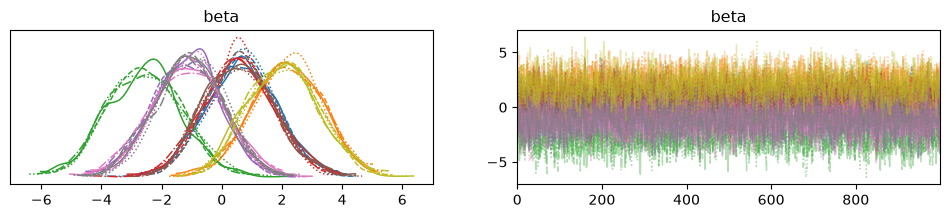

In [5]:
trace_mcmc = mnp_pymc(Y, X)
az.plot_trace(trace_mcmc)

3. <font color = 'orange'> [AI Edit & Human Review]</font> Implement variational inference and plot the posteriors. Does it look reasonable?



Output()

Finished [100%]: Average Loss = 67.466


array([[<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>]], dtype=object)

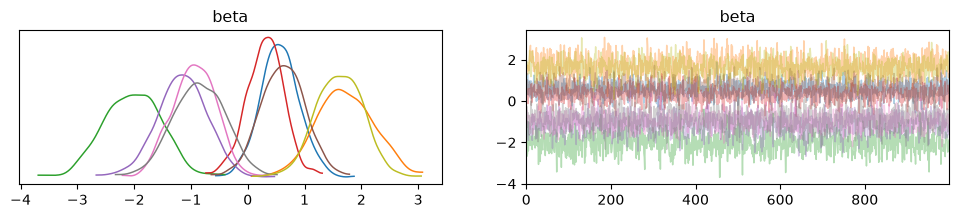

In [6]:
trace_vi = mnp_pymc(Y, X, method='VI')
az.plot_trace(trace_vi)

4. <font color = 'orange'> [AI Edit & Human Review]</font> Now compare the results from MCMC and ADVI against the true coefficients. Also include the standard deviations. How do they compare?

In [7]:
# Function to extract beta estimates and standard deviations from traces
def extract_estimates(trace):
    beta_estimates = az.summary(trace)['mean']
    beta_std = az.summary(trace)['sd']
    return beta_estimates, beta_std

def compare_estimates(true_beta, trace_mcmc, trace_vi):
    # Extract estimates and standard deviations
    true_beta_flat = true_beta.flatten()
    mcmc_estimates, mcmc_std = extract_estimates(trace_mcmc)
    vi_estimates, vi_std = extract_estimates(trace_vi)

    # Create dataframe
    df_data = {
        'True Beta': true_beta_flat,
        'MCMC Estimate': mcmc_estimates,
        'VI Estimate': vi_estimates,
        'MCMC Std': mcmc_std,
        'VI Std': vi_std
    }
    return pd.DataFrame(df_data)

compare_estimates(true_beta, trace_mcmc, trace_vi)

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,True Beta,MCMC Estimate,VI Estimate,MCMC Std,VI Std
"beta[0, 0]",1.0,0.660,0.568,1.156,0.341
"beta[0, 1]",2.5,2.176,1.717,1.164,0.500
"beta[0, 2]",-3.0,-2.570,-2.021,1.242,0.509
"beta[1, 0]",0.5,0.546,0.306,1.162,0.329
"beta[1, 1]",-0.9,-1.172,-1.160,1.125,0.443
"beta[1, 2]",0.5,0.612,0.619,1.155,0.391
"beta[2, 0]",-1.0,-1.123,-0.942,1.183,0.389
"beta[2, 1]",-1.0,-1.074,-0.856,1.123,0.463
"beta[2, 2]",2.0,2.056,1.615,1.175,0.417


***Solution:*** Note that MCMC and VI regularize extreme coefficients (e.g. $\beta = -3$), with VI more so than MCMC. On the other hand, VI generates much tighter distributions.

This is a fairly low-dimensional problem with well-behaved Gaussian priors. However, even in such settings, the number of data points create a computational bottleneck. While we may estimate more accurate posteriors with more data, the likelihood functions need to be computed over all data points in every iteration. Let's see how MCMC and VI compare now.

1. <font color = 'orange'> [AI Edit & Human Review]</font> Generate a new dataset where $N = 10000$.

In [8]:
Y_new, X_new = DGP(10000)

2. <font color = 'purple'> [AI Edit & Design Tests]</font> Now run both MCMC and VI again, sequentially. How could you test AI-generated code for this? How long does each process take? Feel free to kill the process if it exceeds three minutes.

In [9]:
mcmc_new = mnp_pymc(Y_new, X_new)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta]


Output()

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 223 seconds.


In [10]:
vi_new = mnp_pymc(Y_new, X_new, method='VI')

Output()

Finished [100%]: Average Loss = 5,256.5


3. <font color = '701B1B'> [Conceptual]</font> Compare the posterior means and standard deviations to the true $\beta$. How do they compare with a larger sample size?

In [11]:
compare_estimates(true_beta, mcmc_new, vi_new)

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,True Beta,MCMC Estimate,VI Estimate,MCMC Std,VI Std
"beta[0, 0]",1.0,0.874,0.744,1.176,0.155
"beta[0, 1]",2.5,1.816,1.778,0.592,0.201
"beta[0, 2]",-3.0,-2.466,-2.237,0.534,0.239
"beta[1, 0]",0.5,0.396,0.215,1.176,0.159
"beta[1, 1]",-0.9,-1.540,-1.005,0.590,0.180
"beta[1, 2]",0.5,0.993,0.503,0.535,0.169
"beta[2, 0]",-1.0,-1.130,-0.966,1.177,0.181
"beta[2, 1]",-1.0,-1.625,-0.902,0.589,0.174
"beta[2, 2]",2.0,2.487,1.729,0.536,0.217


***Solution:*** MCMC is much slower than VI with $N=10000$. Standard deviations are smaller for both MCMC and VI but the mean does not appear to be significantly more accurate.

4. <font color = 'green'> [AI flexible]</font> An alternative interpretation of the multinomial probit is a latent variable model. As opposed to $Y_i$ being determined from a categorical distribution, it is the $argmax$ of latent utilities $Y_i^* = X_i\beta + \epsilon, \epsilon \sim \mathcal{N}(0, \Sigma)$. However, it is harder to estimate the latent utility model in PyMC (assuming the covariance matrix $\Sigma$ is unknown). There are no ```argmax``` function equivalents in ```pymc.math``` unlike ```NumPy``` since ```argmax``` is discrete and has no computable gradient. Can you find a way to estimate this model? It is important to consider the formulation of the problem and which parameters need to be identified (e.g. whether the underlying covariance matrix $\Sigma$ is necessary). Recent papers have imposed a trace restriction on $
\Sigma$ (see examples [here](https://www.tandfonline.com/doi/abs/10.1080/07350015.2021.1961788) and [here](https://arxiv.org/pdf/2202.12495)) and then performed Bayesian estimation with MCMC and VI.

***Solution:*** With the errors integrated out we do not need $\Sigma$, so we fix $\Sigma=I$ and take cereal 1 as the reference (its coefficients set to 0, a standard normalization). `argmax` is not differentiable in `pymc.math`, so rather than applying it we integrate the latent normal errors out with Gauss–Hermite quadrature and get the choice probabilities directly.

In [12]:
def latent_probit(Y, X, method="MCMC"):
    # Gauss-Hermite quadrature to integrate over the latent normal errors
    nodes, weights = np.polynomial.hermite.hermgauss(20)
    z = np.sqrt(2) * nodes
    weights = weights / np.sqrt(np.pi)

    with pm.Model():
        # cereal 1 is the reference category (its coefficients are fixed to 0)
        beta_free = pm.Normal("beta_free", 0, 2, shape=(X.shape[1], 2))
        beta = pm.Deterministic(
            "beta",
            pm.math.concatenate([pm.math.zeros((X.shape[1], 1)), beta_free], axis=1),
        )
        utility = pm.math.dot(X, beta)

        probabilities = []
        for k in range(3):
            other = [j for j in range(3) if j != k]
            difference = utility[:, k, None] - utility[:, other]
            cdf = pm.math.invprobit(z[None, :, None] + difference[:, None, :])
            probability = pm.math.sum(weights[None, :] * pm.math.prod(cdf, axis=2), axis=1)
            probabilities.append(probability)

        p = pm.math.stack(probabilities, axis=1)
        p /= pm.math.sum(p, axis=1, keepdims=True)
        pm.Multinomial("choice", n=1, p=p, observed=Y)

        if method == "MCMC":
            return pm.sample(1000, tune=1000, chains=2, cores=2, random_seed=42)
        elif method == "VI":
            approx = pm.fit(10_000, method="advi", random_seed=42)
            return approx.sample(1000, random_seed=42)
        raise ValueError("method must be 'MCMC' or 'VI'")

trace_probit = latent_probit(Y, X)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [beta_free]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 5 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


In [13]:
# beta_free holds cereals 2 and 3 relative to cereal 1 (the reference).
# Check that its posterior mean recovers the true cereal differences.
probit_est = trace_probit.posterior["beta_free"].mean(("chain", "draw")).values   # (covariate, 2)
true_diff = (true_beta[1:, :] - true_beta[:1, :]).T                               # (covariate, 2)
pd.DataFrame({
    "true (cereal 2 - 1)":   true_diff[:, 0],
    "probit (cereal 2 - 1)": probit_est[:, 0],
    "true (cereal 3 - 1)":   true_diff[:, 1],
    "probit (cereal 3 - 1)": probit_est[:, 1],
}, index=["Intercept", "X1", "X2"]).round(2)

,true (cereal 2 - 1),probit (cereal 2 - 1),true (cereal 3 - 1),probit (cereal 3 - 1)
Intercept,-0.5,-0.14,-2.0,-1.31
X1,-3.4,-2.37,-3.5,-2.17
X2,3.5,2.21,5.0,3.23


The probit recovers the same cereal preferences as the data-generating logit. The signs and ordering of the estimated differences match the truth, but at a smaller magnitude, because its error variance differs from the logit's.

## Exercise: Data Generation

This is an open-ended exercise where we have provided a random 50% sample of an ACS data extract from IPUMS. The goal is to generate the other 50% of the data using numerical sampling methods discussed in the module.

Please use the cleaned ```.dta``` file in the ```data``` folder. We have provided the following variables:

*   Demographics: ```AGE``` and ```RACE```.
*   Educational attainment: ```EDUC```.
*   Employment status and occupation: ```EMPSTAT``` and ```OCC```.
*   Income: ```INCTOT``` and ```FTOTINC``` for total personal and family income, respectively.

We also include identifier variables that do not need to be simulated:
*   ```YEAR```: Indicates the Census year (2015, 2016, or 2017).
*   Geography: ```COUNTYFIP``` indicates the FIPS code of the county. The data sample is only of New York City so the ```CITY``` variable is constant.
*   Identifiers: ```SERIAL``` is the household serial number and ```PERNUM``` indicates the person number within a sampled household. Each unique observation within a Census year is a combination of ```SERIAL``` and ```PERNUM```.

The detailed codebook for each variable can be found in ```codebook.txt``` also in the ```data``` folder.

In [14]:
import matplotlib.pyplot as plt

# Load the ACS extract and focus on the 2015 cross-section 
acs = pd.read_stata("data/ipums_new_york_2015_2017_sample_50.dta", convert_categoricals=False)
acs = acs[acs["year"] == 2015]
print(f"{len(acs):,} people in the 2015 sample")

176,231 people in the 2015 sample


### Demographics

<font color = 'orange'> [AI Edit & Human Review]</font> We provide demographic data on ```AGE``` and ```RACE```. Plot out the distributions and simulate data based on this.

<font color = '701B1B'> [Conceptual]</font> Which distributions have you chosen for the demographic variables and why?

***Solution:*** `AGE` and `RACE` are discrete and irregularly shaped, so no standard parametric family fits them well. We sample each directly from its empirical distribution — drawing observed values with replacement — which reproduces the observed distribution by construction and needs no distributional assumption.

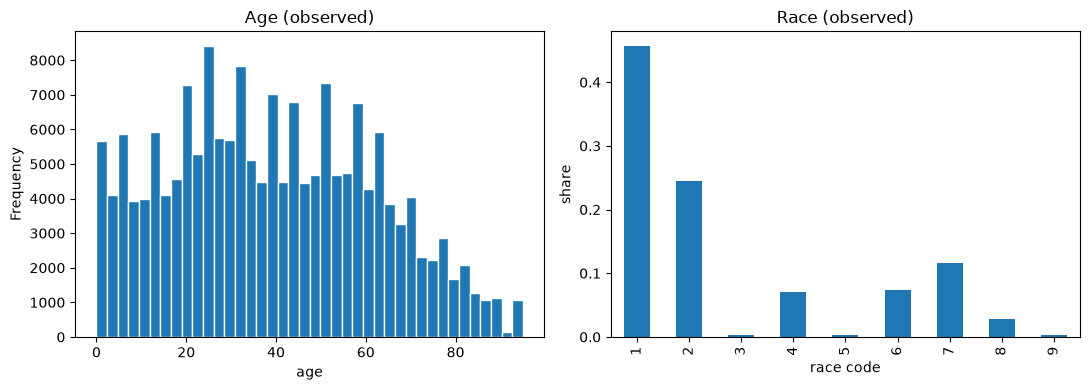

In [15]:
# Observed distributions
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
acs["age"].plot.hist(bins=40, ax=ax[0], edgecolor="white")
ax[0].set(title="Age (observed)", xlabel="age")
acs["race"].value_counts(normalize=True).sort_index().plot.bar(ax=ax[1])
ax[1].set(title="Race (observed)", xlabel="race code", ylabel="share")
plt.tight_layout(); plt.show()

In [16]:
# Sample each variable from its empirical distribution (observed values drawn with replacement).
rng = np.random.default_rng(0)
n = len(acs)
sim_demog = pd.DataFrame({
    "age":  rng.choice(acs["age"].values,  size=n, replace=True),
    "race": rng.choice(acs["race"].values, size=n, replace=True),
})
sim_demog.head()

,age,race
0,25,1
1,11,1
2,44,1
3,26,1
4,8,4


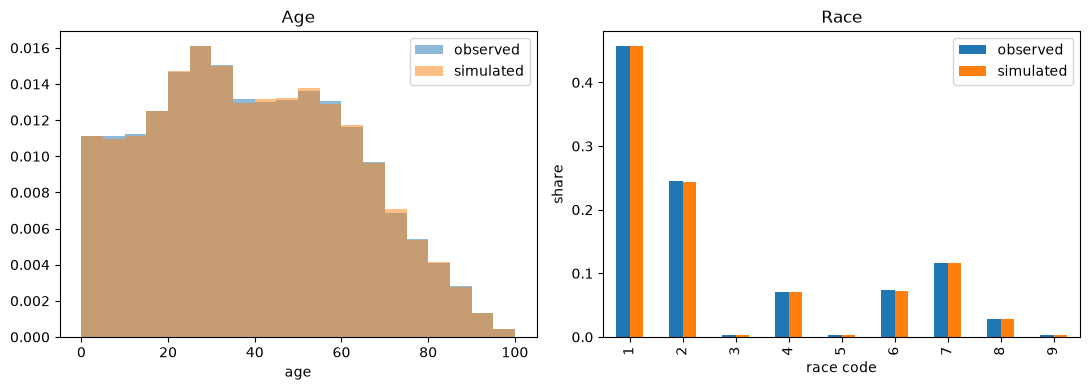

In [17]:
# Compare observed and simulated
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
bins = np.arange(0, 101, 5)
ax[0].hist(acs["age"], bins=bins, density=True, alpha=0.5, label="observed")
ax[0].hist(sim_demog["age"], bins=bins, density=True, alpha=0.5, label="simulated")
ax[0].set(title="Age", xlabel="age"); ax[0].legend()
pd.DataFrame({"observed":  acs["race"].value_counts(normalize=True),
             "simulated": sim_demog["race"].value_counts(normalize=True)}).sort_index().plot.bar(ax=ax[1])
ax[1].set(title="Race", xlabel="race code", ylabel="share")
plt.tight_layout(); plt.show()

### Earnings
Now we will focus just on jointly simulating family income (```FTOTINC```) and individual income (```INCTOT```) from 2015.

1. <font color = 'orange'> [AI Edit & Human Review]</font> Plot out the joint income distributions. Briefly describe the variables.

2. <font color = '701B1B'> [Conceptual]</font> Based on your plot and economic intuition, what might an appropriate interdependence relationship between the two variables be?

3. <font color = 'purple'> [AI Edit & Design Tests]</font> Use the approach you described in the preceding question to simulate data from the joint distribution of family income and individual income. Design a test to make sure the simulated data is correct.

4. <font color = 'purple'> [AI Edit & Design Tests]</font> Now, try jointly simulating occupation (a categorical variable) and incomes?

***Solution:*** **(1)** We are given individual income (`INCTOT`) and total family income (`FTOTINC`). The first plot shows they are mechanically linked: `FTOTINC >= INCTOT` (a person's income is part of their family's). Simulating the pair `(FTOTINC, INCTOT)` directly is therefore awkward — every draw would have to respect `FTOTINC >= INCTOT`. Instead we split family income into the individual's income plus the rest of the family's income, `rest = FTOTINC - INCTOT`, and simulate the two components `(INCTOT, rest)`. Family income is then simply their sum.

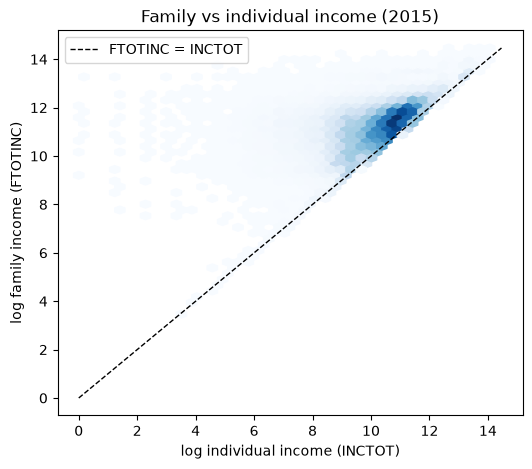

correlation of log INCTOT and log FTOTINC: 0.568


In [18]:
# Keep 2015 people with valid, positive individual and family income.
earn = acs[(acs["inctot"] > 0) & (acs["inctot"] < 9999999) & (acs["ftotinc"] < 9999999)].copy()
earn["rest"] = earn["ftotinc"] - earn["inctot"]
earn = earn[earn["rest"] > 0]

# Individual vs family income (log scale). Points sit on or above the 45-degree line
# FTOTINC = INCTOT, because a person's income is part of their family's income.
plt.figure(figsize=(6, 5))
plt.hexbin(np.log(earn["inctot"]), np.log(earn["ftotinc"]), gridsize=40, cmap="Blues", mincnt=1)
lo, hi = np.log(earn["inctot"]).min(), np.log(earn["ftotinc"]).max()
plt.plot([lo, hi], [lo, hi], "k--", lw=1, label="FTOTINC = INCTOT")
plt.xlabel("log individual income (INCTOT)"); plt.ylabel("log family income (FTOTINC)")
plt.legend(); plt.title("Family vs individual income (2015)"); plt.show()
print("correlation of log INCTOT and log FTOTINC:", round(np.log(earn["inctot"]).corr(np.log(earn["ftotinc"])), 3))

**(2)** Within a family, individual income and the rest of the family's income are positively related — households sort together (assortative matching) and share circumstances — so they are not independent. Both are positive, right-skewed and heavy-tailed. We simulate them jointly with a copula: a lognormal marginal for each (a good fit for skewed positive incomes) and a Gaussian copula to carry the observed dependence. We use 2015 and drop the `9999999` N/A codes, keeping people with positive individual and rest income.

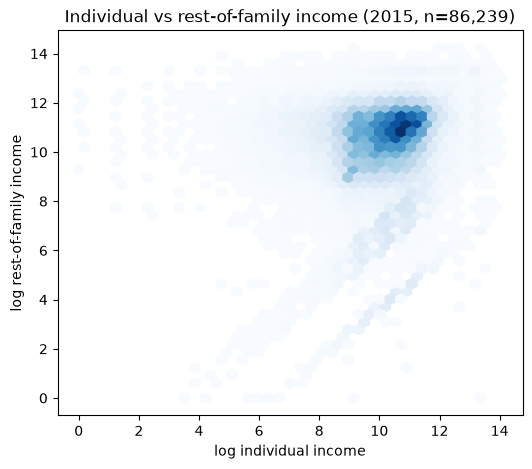

Spearman correlation in the data: 0.127


In [19]:
# Joint distribution of the two components we simulate: individual and rest-of-family income.
plt.figure(figsize=(6, 5))
plt.hexbin(np.log(earn["inctot"]), np.log(earn["rest"]), gridsize=40, cmap="Blues", mincnt=1)
plt.xlabel("log individual income"); plt.ylabel("log rest-of-family income")
plt.title(f"Individual vs rest-of-family income (2015, n={len(earn):,})"); plt.show()
print("Spearman correlation in the data:", round(earn["inctot"].corr(earn["rest"], method="spearman"), 3))

In [20]:
# Lognormal marginals: log(income) is normal, so fit the mean and sd of each log-income.
li, lr = np.log(earn["inctot"].values), np.log(earn["rest"].values)
mi, si = li.mean(), li.std()
mr, sr = lr.mean(), lr.std()

# Gaussian copula: its dependence parameter is the correlation of the normal scores,
# which for lognormal marginals are just the standardized logs.
rho = np.corrcoef((li - mi) / si, (lr - mr) / sr)[0, 1]

# Simulate: draw correlated normal scores, then map each back through its lognormal marginal.
rng = np.random.default_rng(0)
Z = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], size=len(earn))
sim_inc  = np.exp(mi + si * Z[:, 0])
sim_rest = np.exp(mr + sr * Z[:, 1])
sim_ftotinc = sim_inc + sim_rest
print(f"copula correlation rho = {rho:.3f}")

copula correlation rho = 0.099


In [21]:
# Test: the simulated logs are normal with the fitted means, sds, and correlation.
assert abs(np.mean(np.log(sim_inc))  - mi) < 0.05
assert abs(np.mean(np.log(sim_rest)) - mr) < 0.05
assert abs(np.corrcoef(np.log(sim_inc), np.log(sim_rest))[0, 1] - rho) < 0.05
print("tests passed. median income (data vs simulated):")
print(f"  individual: {earn['inctot'].median():>8.0f}  vs {np.median(sim_inc):>8.0f}")
print(f"  rest      : {earn['rest'].median():>8.0f}  vs {np.median(sim_rest):>8.0f}")
print(f"  family    : {earn['ftotinc'].median():>8.0f}  vs {np.median(sim_ftotinc):>8.0f}")

tests passed. median income (data vs simulated):
  individual:    27912  vs    23989
  rest      :    40720  vs    26734
  family    :    80240  vs    72890


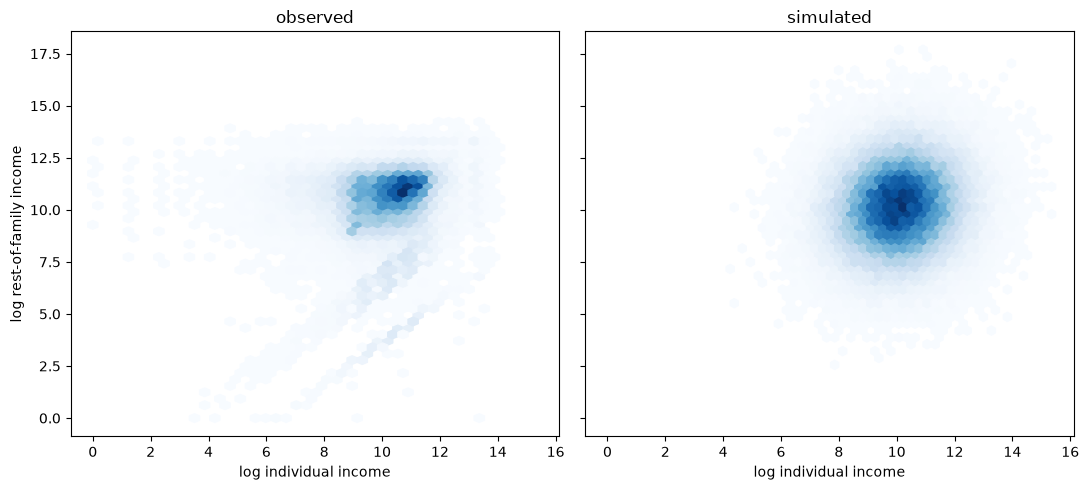

In [22]:
# Observed vs simulated joint distribution
fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
ax[0].hexbin(li, lr, gridsize=40, cmap="Blues", mincnt=1)
ax[0].set(title="observed", xlabel="log individual income", ylabel="log rest-of-family income")
ax[1].hexbin(np.log(sim_inc), np.log(sim_rest), gridsize=40, cmap="Blues", mincnt=1)
ax[1].set(title="simulated", xlabel="log individual income")
plt.tight_layout(); plt.show()

The copula reproduces the weak positive dependence. The lognormal marginals are only approximate.

***Solution:*** **(4)** Income differs sharply across occupations, so we simulate occupation from its empirical distribution, then draw income from a lognormal fitted to that occupation's own incomes. Occupations with a single worker have no spread to estimate, so we use the pooled standard deviation there.

In [23]:
# Workers in 2015 with a positive income and a recorded occupation.
work = acs[(acs["inctot"] > 0) & (acs["inctot"] < 9999999) & (acs["occ"] > 0)].copy()
work["loginc"] = np.log(work["inctot"])

# Fit a lognormal to income within each occupation (mean and sd of log income).
occ_fit = work.groupby("occ")["loginc"].agg(["mean", "std"])
occ_fit["std"] = occ_fit["std"].fillna(work["loginc"].std())   # 1-worker occupations have no spread

# Simulate occupation from its empirical distribution, then income from that occupation's lognormal.
rng = np.random.default_rng(0)
sim_occ = rng.choice(work["occ"].values, size=len(work), replace=True)
mu = pd.Series(sim_occ).map(occ_fit["mean"]).values
sd = pd.Series(sim_occ).map(occ_fit["std"]).values
sim_occ_inc = np.exp(mu + sd * rng.standard_normal(len(work)))
print(f"simulated {len(sim_occ_inc):,} (occupation, income) pairs")

simulated 94,487 (occupation, income) pairs


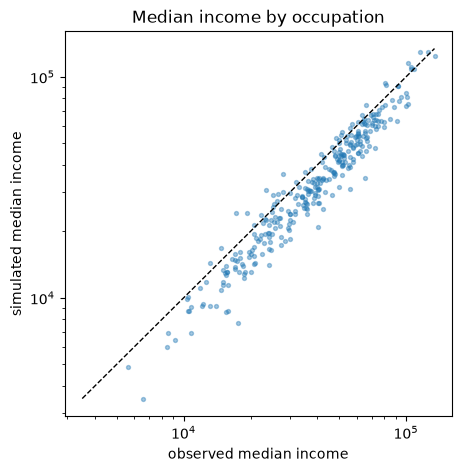

correlation (log scale): 0.969


In [24]:
# Check: median income by occupation should line up between observed and simulated data.
sim_df = pd.DataFrame({"occ": sim_occ, "inc": sim_occ_inc})
big = work["occ"].value_counts()
big = big[big >= 30].index                                     # occupations with enough data to compare
comp = pd.DataFrame({"observed":  work.groupby("occ")["inctot"].median(),
                     "simulated": sim_df.groupby("occ")["inc"].median()}).loc[big].dropna()

plt.figure(figsize=(5, 5))
plt.scatter(comp["observed"], comp["simulated"], s=8, alpha=0.4)
lims = [comp.values.min(), comp.values.max()]
plt.plot(lims, lims, "k--", lw=1)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("observed median income"); plt.ylabel("simulated median income")
plt.title("Median income by occupation"); plt.show()
print("correlation (log scale):", round(np.log(comp["observed"]).corr(np.log(comp["simulated"])), 3))

Each occupation's simulated income tracks its observed level (the points are close to the 45° line), so occupation and income are not independent in the simulated data.

### Open-Ended Exploration

<font color = 'green'> [AI flexible]</font> Simulate more variables of your choosing and keep in mind the interdependencies present between different variables. You do not have to simulate all of them, but may select a subset to focus on. We advise focusing first on simulating cross-sectional data (e.g. from 2015).

<font color = 'green'> [AI flexible]</font> Now, given the panel data, simulate your selected variables forward to 2016 and 2017.

<font color = '701B1B'> [Conceptual]</font> What sampling methods did you use and why?

# Submission ⭐

Congratulations you finished this module! We will handle all exercise submissions on GitHub classroom. In order to access this assignment, you should already have a GitHub account with an associated repository unique to you. Please submit the assignment in that repository.